# Финальная работа "Модель кредитного риск-менеджмента"
Атрибуты данных
- id — идентификатор заявки. Заявки пронумерованы так, что большему номеру соответствует более поздняя дата заявки.
- rn — порядковый номер кредитного продукта в кредитной истории. Большему номеру соответствует продукт с более поздней датой открытия. 
- pre_since_opened — количество дней с даты открытия кредита до даты сбора данных (бинаризовано*). 
- pre_since_confirmed — количество дней с даты подтверждения информации по кредиту до даты сбора данных (бинаризовано*). 
- pre_pterm — плановое количество дней с даты открытия кредита до даты закрытия (бинаризовано*). 
- pre_fterm — фактическое количество дней с даты открытия кредита до даты закрытия (бинаризовано*).
- pre_till_pclose — плановое количество дней с даты сбора данных до даты закрытия кредита (бинаризовано*). 
- pre_till_fclose — фактическое количество дней с даты сбора данных до даты закрытия кредита (бинаризовано*). 
- pre_loans_credit_limit  — кредитный лимит (бинаризовано*). 
- pre_loans_next_pay_summ — сумма следующего платежа по кредиту (бинаризовано*). 
- pre_loans_outstanding — оставшаяся невыплаченная сумма кредита (бинаризовано*). 
- pre_loans_total_overdue — текущая просроченная задолженность (бинаризовано*). 
- pre_loans_max_overdue_sum — максимальная просроченная задолженность (бинаризовано*). 
- pre_loans_credit_cost_rate — полная стоимость кредита (бинаризовано*). 
- pre_loans5 — число просрочек до 5 дней (бинаризовано*). 
- pre_loans530 — число просрочек от 5 до 30 дней (бинаризовано*). 
- pre_loans3060 — число просрочек от 30 до 60 дней (бинаризовано*). 
- pre_loans6090 — число просрочек от 60 до 90 дней (бинаризовано*). 
- pre_loans90 — число просрочек более чем на 90 дней (бинаризовано*). 
- is_zero_loans_5 — флаг: нет просрочек до 5 дней. 
- is_zero_loans_530 — флаг: нет просрочек от 5 до 30 дней. 
- is_zero_loans_3060 — флаг: нет просрочек от 30 до 60 дней. 
- is_zero_loans_6090 — флаг: нет просрочек от 60 до 90 дней. 
- is_zero_loans90 — флаг: нет просрочек более чем на 90 дней. 
- pre_util — отношение оставшейся невыплаченной суммы кредита
 к кредитному лимиту (бинаризовано*). 
 - pre_over2limit — отношение текущей просроченной задолженности
 к кредитному лимиту (бинаризовано*).
- pre_maxover2limit — отношение максимальной просроченной задолженности к кредитному лимиту (бинаризовано*). 
- is_zero_util — флаг: отношение оставшейся невыплаченной суммы кредита к кредитному лимиту равно 0. 
- is_zero_over2limit — флаг: отношение текущей просроченной задолженности к кредитному лимиту равно 0. 
- is_zero_maxover2limit — флаг: отношение максимальной просроченной задолженности к кредитному лимиту равно 0. 
- enc_paym_{0..N} — статусы ежемесячных платежей за последние N месяцев (закодировано**). - enc_loans_account_holder_type — тип отношения к кредиту (закодировано**). 
- enc_loans_credit_status — статус кредита (закодировано**). 
- enc_loans_account_cur — валюта кредита (закодировано**). 
- enc_loans_credit_type — тип кредита (закодировано**). 
- pclose_flag — флаг: плановое количество дней с даты открытия кредита до даты закрытия не определено. 
- fclose_flag — флаг: фактическое количество дней с даты открытия кредита до даты закрытия не определено.

\* Область значений поля разбивается на N непересекающихся промежутков. 
Каждому промежутку случайным образом назначается уникальный номер от 0 до N-1, а значение поля заменяется номером промежутка, которому оно принадлежит.

In [1]:
# Импорт всех используемых библиотек
import os
import pandas as pd
import dill
import tqdm
import lightgbm as lgb
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import roc_curve
from datetime import datetime
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
path = 'train_data/'

def read_parquet_dataset_from_local(path_to_dataset: str, start_from: int = 0,
                                     num_parts_to_read: int = 2, columns=None, verbose=False) -> pd.DataFrame:
    """
    читает num_parts_to_read партиций, преобразовывает их к pd.DataFrame и возвращает
    :param path_to_dataset: путь до директории с партициями
    :param start_from: номер партиции, с которой нужно начать чтение
    :param num_parts_to_read: количество партиций, которые требуется прочитать
    :param columns: список колонок, которые нужно прочитать из партиции
    :return: pd.DataFrame
    """

    res = []
    dataset_paths = sorted([os.path.join(path_to_dataset, filename) for filename in os.listdir(path_to_dataset)
                              if filename.startswith('train')])
    print(dataset_paths)

    start_from = max(0, start_from)
    chunks = dataset_paths[start_from: start_from + num_parts_to_read]
    if verbose:
        print('Reading chunks:\n')
        for chunk in chunks:
            print(chunk)
    for chunk_path in tqdm.tqdm_notebook(chunks, desc="Reading dataset with pandas"):
        print('chunk_path', chunk_path)
        chunk = pd.read_parquet(chunk_path,columns=columns)
        res.append(chunk)

    return pd.concat(res)

In [3]:
def prepare_transactions_dataset(path_to_dataset: str, num_parts_to_preprocess_at_once: int = 1, num_parts_total: int=50,
                                 save_to_path=None, verbose: bool=False):
    """
    возвращает готовый pd.DataFrame с признаками, на которых можно учить модель для целевой задачи
    path_to_dataset: str
        путь до датасета с партициями
    num_parts_to_preprocess_at_once: int
        количество партиций, которые будут одновременно держаться и обрабатываться в памяти
    num_parts_total: int
        общее количество партиций, которые нужно обработать
    save_to_path: str
        путь до папки, в которой будет сохранён каждый обработанный блок в .parquet-формате; если None, то не будет сохранён
    verbose: bool
        логирует каждую обрабатываемую часть данных
    """
    preprocessed_frames = []

    for step in tqdm.tqdm_notebook(range(0, num_parts_total, num_parts_to_preprocess_at_once),
                                   desc="Transforming transactions data"):
        transactions_frame = read_parquet_dataset_from_local(path_to_dataset, step, num_parts_to_preprocess_at_once,
                                                             verbose=verbose)

   #записываем подготовленные данные в файл
        if save_to_path:
            block_as_str = str(step)
            if len(block_as_str) == 1:
                block_as_str = '00' + block_as_str
            else:
                block_as_str = '0' + block_as_str
            transactions_frame.to_parquet(os.path.join(save_to_path, f'processed_chunk_{block_as_str}.parquet'))

        preprocessed_frames.append(transactions_frame)
    return pd.concat(preprocessed_frames)

In [4]:
data = prepare_transactions_dataset(path, num_parts_to_preprocess_at_once=2, num_parts_total=12,
                                    save_to_path='train_data/')

Transforming transactions data:   0%|          | 0/6 [00:00<?, ?it/s]

['train_data/train_data_0.pq', 'train_data/train_data_1.pq', 'train_data/train_data_10.pq', 'train_data/train_data_11.pq', 'train_data/train_data_2.pq', 'train_data/train_data_3.pq', 'train_data/train_data_4.pq', 'train_data/train_data_5.pq', 'train_data/train_data_6.pq', 'train_data/train_data_7.pq', 'train_data/train_data_8.pq', 'train_data/train_data_9.pq']


Reading dataset with pandas:   0%|          | 0/2 [00:00<?, ?it/s]

chunk_path train_data/train_data_0.pq
chunk_path train_data/train_data_1.pq
['train_data/train_data_0.pq', 'train_data/train_data_1.pq', 'train_data/train_data_10.pq', 'train_data/train_data_11.pq', 'train_data/train_data_2.pq', 'train_data/train_data_3.pq', 'train_data/train_data_4.pq', 'train_data/train_data_5.pq', 'train_data/train_data_6.pq', 'train_data/train_data_7.pq', 'train_data/train_data_8.pq', 'train_data/train_data_9.pq']


Reading dataset with pandas:   0%|          | 0/2 [00:00<?, ?it/s]

...

chunk_path train_data/train_data_4.pq
chunk_path train_data/train_data_5.pq
['train_data/train_data_0.pq', 'train_data/train_data_1.pq', 'train_data/train_data_10.pq', 'train_data/train_data_11.pq', 'train_data/train_data_2.pq', 'train_data/train_data_3.pq', 'train_data/train_data_4.pq', 'train_data/train_data_5.pq', 'train_data/train_data_6.pq', 'train_data/train_data_7.pq', 'train_data/train_data_8.pq', 'train_data/train_data_9.pq']


Reading dataset with pandas:   0%|          | 0/2 [00:00<?, ?it/s]

chunk_path train_data/train_data_6.pq
chunk_path train_data/train_data_7.pq
['train_data/train_data_0.pq', 'train_data/train_data_1.pq', 'train_data/train_data_10.pq', 'train_data/train_data_11.pq', 'train_data/train_data_2.pq', 'train_data/train_data_3.pq', 'train_data/train_data_4.pq', 'train_data/train_data_5.pq', 'train_data/train_data_6.pq', 'train_data/train_data_7.pq', 'train_data/train_data_8.pq', 'train_data/train_data_9.pq']


Reading dataset with pandas:   0%|          | 0/2 [00:00<?, ?it/s]

chunk_path train_data/train_data_8.pq
chunk_path train_data/train_data_9.pq


In [5]:
data.head()

,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,...,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag
0,0,1,18,9,2,3,16,10,11,3,...,3,3,3,4,1,3,4,1,0,0
1,0,2,18,9,14,14,12,12,0,3,...,0,0,0,4,1,3,4,1,0,0
2,0,3,18,9,4,8,1,11,11,0,...,0,0,0,4,1,2,3,1,1,1
3,0,4,4,1,9,12,16,7,12,2,...,3,3,3,4,1,3,1,1,0,0
4,0,5,5,12,15,2,11,12,10,2,...,3,3,3,4,1,3,4,1,0,0


In [68]:
data.head(10).to_json('2.json', orient='records')

Создадим копию датфрейма для работы

In [6]:
df = data.copy()

In [7]:
targets = pd.read_csv('train_target.csv')
targets.head()

,id,flag
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


In [8]:
targets.flag.value_counts()

flag
0    2893558
1     106442
Name: count, dtype: int64

Выборка не сбалансирована

# Data Preparation

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26162717 entries, 0 to 2284255
Data columns (total 61 columns):
 #   Column                         Dtype
---  ------                         -----
 0   id                             int64
 1   rn                             int64
 2   pre_since_opened               int64
 3   pre_since_confirmed            int64
 4   pre_pterm                      int64
 5   pre_fterm                      int64
 6   pre_till_pclose                int64
 7   pre_till_fclose                int64
 8   pre_loans_credit_limit         int64
 9   pre_loans_next_pay_summ        int64
 10  pre_loans_outstanding          int64
 11  pre_loans_total_overdue        int64
 12  pre_loans_max_overdue_sum      int64
 13  pre_loans_credit_cost_rate     int64
 14  pre_loans5                     int64
 15  pre_loans530                   int64
 16  pre_loans3060                  int64
 17  pre_loans6090                  int64
 18  pre_loans90                    int64
 19  is_z

Видно что все типы данных датафрейма имеют тип int64, что сильно загружает ОЗУ. Все признаки кроме id преобразуем в int8 для освобождения памяти.

In [10]:
columns_data = df.columns[1:]
df[columns_data] = df[columns_data].astype('int8')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26162717 entries, 0 to 2284255
Data columns (total 61 columns):
 #   Column                         Dtype
---  ------                         -----
 0   id                             int64
 1   rn                             int8 
 2   pre_since_opened               int8 
 3   pre_since_confirmed            int8 
 4   pre_pterm                      int8 
 5   pre_fterm                      int8 
 6   pre_till_pclose                int8 
 7   pre_till_fclose                int8 
 8   pre_loans_credit_limit         int8 
 9   pre_loans_next_pay_summ        int8 
 10  pre_loans_outstanding          int8 
 11  pre_loans_total_overdue        int8 
 12  pre_loans_max_overdue_sum      int8 
 13  pre_loans_credit_cost_rate     int8 
 14  pre_loans5                     int8 
 15  pre_loans530                   int8 
 16  pre_loans3060                  int8 
 17  pre_loans6090                  int8 
 18  pre_loans90                    int8 
 19  is_z

Соединим датафрейм data с целевой переменной target по индексу

In [11]:
df = df.merge(targets[['id', 'flag']], on='id', how='left')
df.head()

,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,...,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag,flag
0,0,1,18,9,2,3,16,10,11,3,...,3,3,4,1,3,4,1,0,0,0
1,0,2,18,9,14,14,12,12,0,3,...,0,0,4,1,3,4,1,0,0,0
2,0,3,18,9,4,8,1,11,11,0,...,0,0,4,1,2,3,1,1,1,0
3,0,4,4,1,9,12,16,7,12,2,...,3,3,4,1,3,1,1,0,0,0
4,0,5,5,12,15,2,11,12,10,2,...,3,3,4,1,3,4,1,0,0,0


In [12]:
df['flag'] = df['flag'].astype('int8')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26162717 entries, 0 to 26162716
Data columns (total 62 columns):
 #   Column                         Dtype
---  ------                         -----
 0   id                             int64
 1   rn                             int8 
 2   pre_since_opened               int8 
 3   pre_since_confirmed            int8 
 4   pre_pterm                      int8 
 5   pre_fterm                      int8 
 6   pre_till_pclose                int8 
 7   pre_till_fclose                int8 
 8   pre_loans_credit_limit         int8 
 9   pre_loans_next_pay_summ        int8 
 10  pre_loans_outstanding          int8 
 11  pre_loans_total_overdue        int8 
 12  pre_loans_max_overdue_sum      int8 
 13  pre_loans_credit_cost_rate     int8 
 14  pre_loans5                     int8 
 15  pre_loans530                   int8 
 16  pre_loans3060                  int8 
 17  pre_loans6090                  int8 
 18  pre_loans90                    int8 
 19

### Data cleaning

In [14]:
# Проверка на наличие пропущенных значений
(df.isna().sum()/len(df)>0).sum()

0

Пропущенных значений в датасете нет

In [15]:
# Проверка на дубликаты
df.duplicated().sum()

0

Дубликатов в данных нет

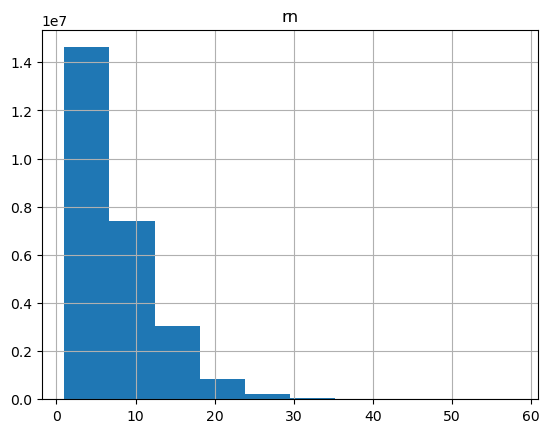

rn
1     3000000
2     2779455
3     2550810
4     2320731
5     2094188
6     1876509
7     1668536
8     1473997
9     1294408
10    1130303
11     982254
12     850192
13     733250
14     630295
15     540573
16     457926
17     383308
18     315058
19     254553
20     201566
21     156755
22     120002
23      90835
24      67755
25      50452
26      37382
27      27698
28      20450
29      15053
30      11050
31       8006
32       5815
33       4185
34       2964
35       2063
36       1447
37        987
38        662
39        441
40        280
41        178
42        123
43         75
44         41
45         32
46         17
47         12
48         10
49          9
50          7
51          5
52          3
53          3
54          3
55          2
56          1
57          1
58          1
Name: count, dtype: int64


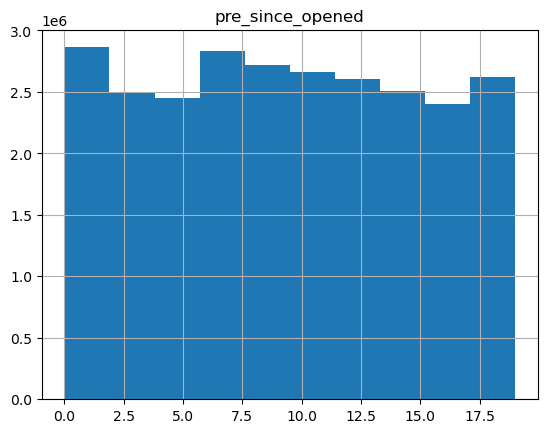

pre_since_opened
13    1645938
0     1561873
6     1522882
10    1409770
8     1406244
18    1388400
14    1315095
9     1312790
7     1307521
1     1300842
2     1290724
4     1255220
11    1250266
19    1230414
3     1211933
17    1202495
16    1200566
5     1196677
15    1193193
12     959874
Name: count, dtype: int64


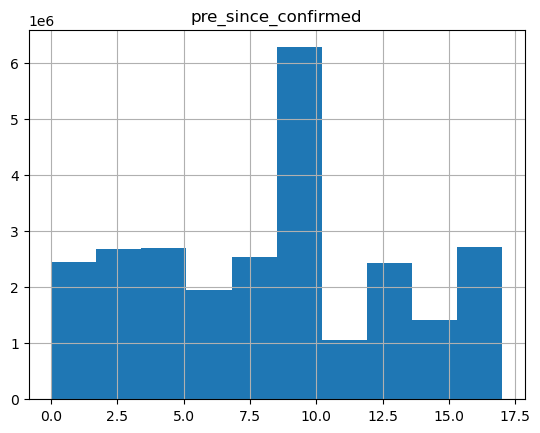

pre_since_confirmed
9     4909419
6     1948337
4     1514861
17    1503451
3     1435553
14    1410504
10    1361991
13    1313856
7     1291490
1     1245131
2     1239514
8     1234641
16    1213550
0     1192383
5     1180787
12    1108831
11    1058230
15        188
Name: count, dtype: int64


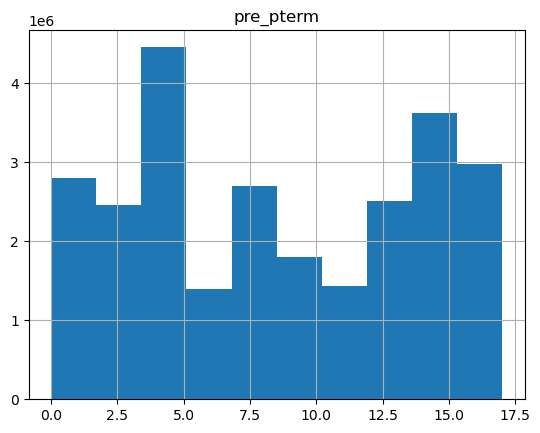

pre_pterm
4     4456185
14    2336504
2     1532229
17    1520418
1     1483207
16    1460983
11    1430459
9     1428200
6     1400005
7     1391864
0     1312386
13    1310140
8     1307841
15    1294553
12    1205634
3      923202
10     367939
5         968
Name: count, dtype: int64


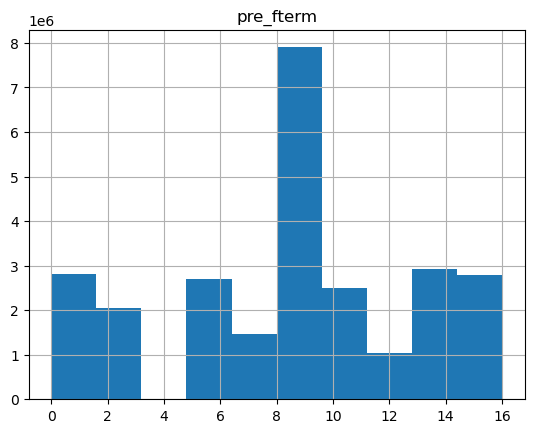

pre_fterm
8     6204663
9     1695807
0     1597751
14    1566914
6     1493807
16    1463400
7     1460416
13    1363752
15    1323654
11    1303353
1     1207377
5     1204894
10    1199907
2     1175844
12    1034805
3      866017
4         356
Name: count, dtype: int64


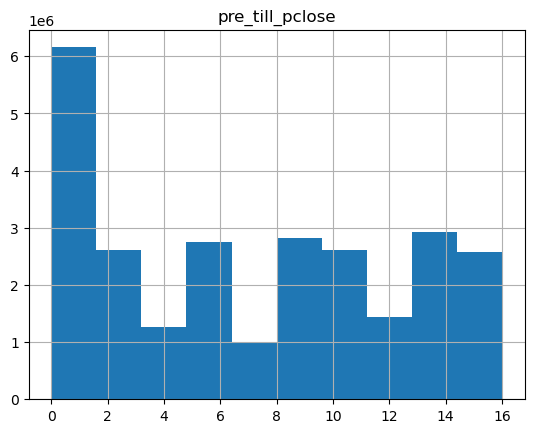

pre_till_pclose
1     4910941
8     1499795
13    1466470
14    1451729
12    1441898
3     1419577
6     1395040
5     1357688
9     1327500
10    1323903
16    1317347
11    1295073
4     1263147
15    1257003
0     1246379
2     1188430
7     1000797
Name: count, dtype: int64


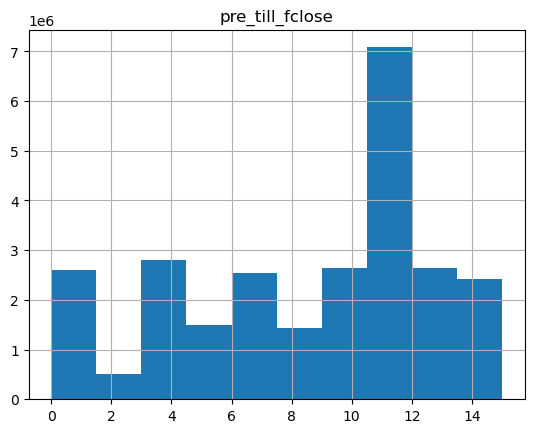

pre_till_fclose
11    7082796
5     1491932
3     1490175
8     1427444
10    1377705
13    1360559
1     1326558
4     1307602
7     1300230
12    1289604
0     1274251
14    1267633
9     1259756
6     1245281
15    1158211
2      502980
Name: count, dtype: int64


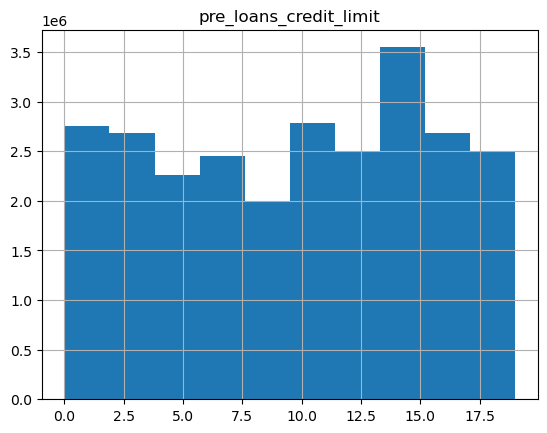

pre_loans_credit_limit
14    2136533
19    1459193
11    1422358
15    1411541
0     1408767
7     1383034
8     1375453
2     1366620
10    1360834
16    1352225
1     1344645
17    1334265
3     1317776
12    1317679
13    1189610
5     1177987
4     1082617
6     1071644
18    1032370
9      617566
Name: count, dtype: int64


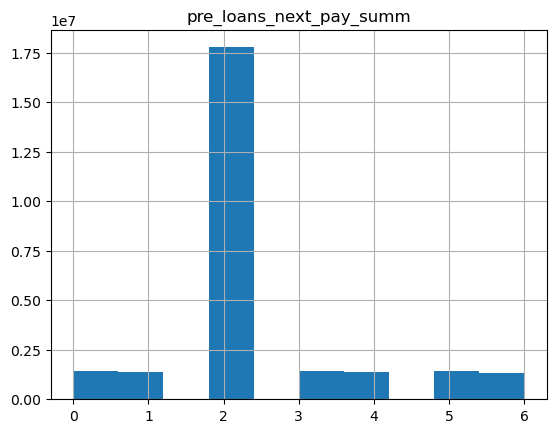

pre_loans_next_pay_summ
2    17777162
0     1452141
5     1438360
3     1406202
1     1382525
4     1372003
6     1334324
Name: count, dtype: int64


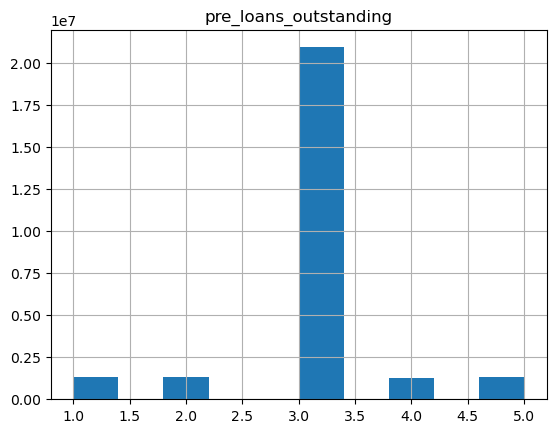

pre_loans_outstanding
3    20909470
1     1343015
2     1316280
5     1306107
4     1287845
Name: count, dtype: int64


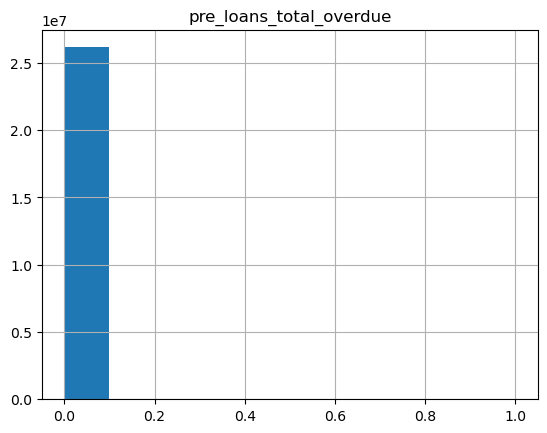

pre_loans_total_overdue
0    26162716
1           1
Name: count, dtype: int64


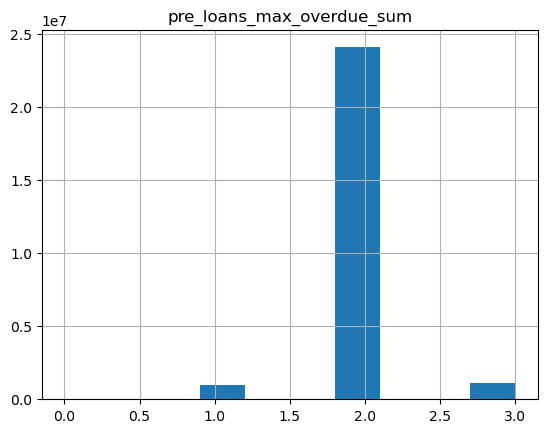

pre_loans_max_overdue_sum
2    24071329
3     1113827
1      977560
0           1
Name: count, dtype: int64


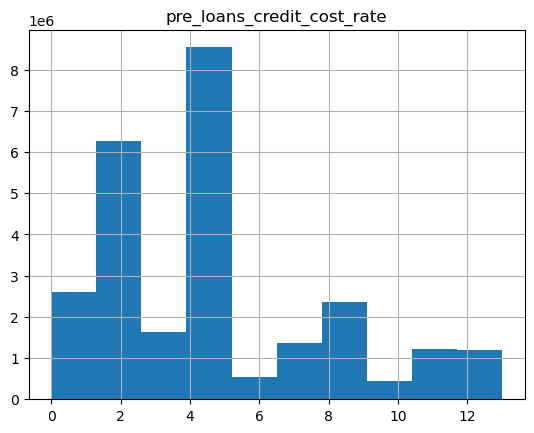

pre_loans_credit_cost_rate
4     7018834
2     6262438
3     1638369
5     1524119
9     1375623
1     1357623
7     1355353
0     1242721
11    1215253
13    1187225
8      987541
6      552788
10     444745
12         85
Name: count, dtype: int64


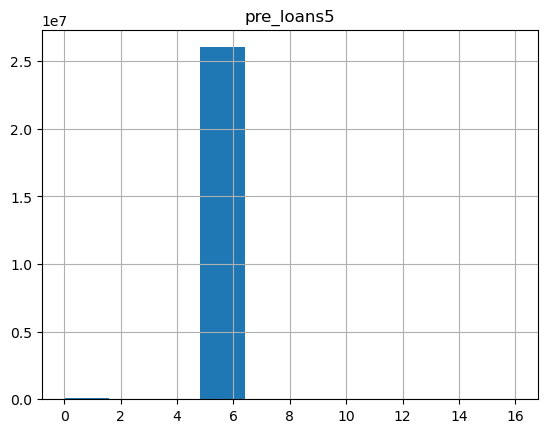

pre_loans5
6     26019398
0        95329
3        28998
5        11810
2         4386
16        1766
13         640
7          250
1           91
8           32
9           13
11           3
10           1
Name: count, dtype: int64


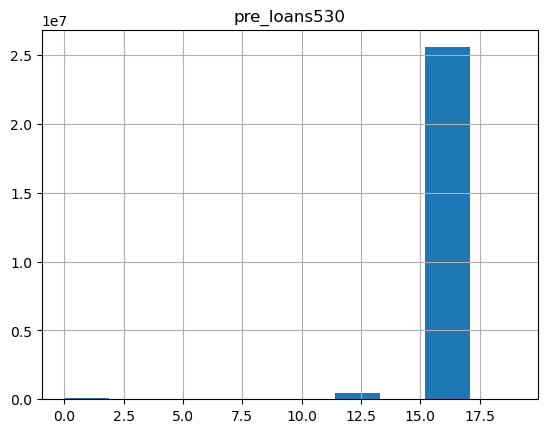

pre_loans530
16    25550977
13      422128
0       110507
18       42054
6        19217
3         9117
2         4433
12        2185
15         864
4          575
14         337
1          138
10          91
19          36
7           29
11          16
5            5
9            4
8            3
17           1
Name: count, dtype: int64


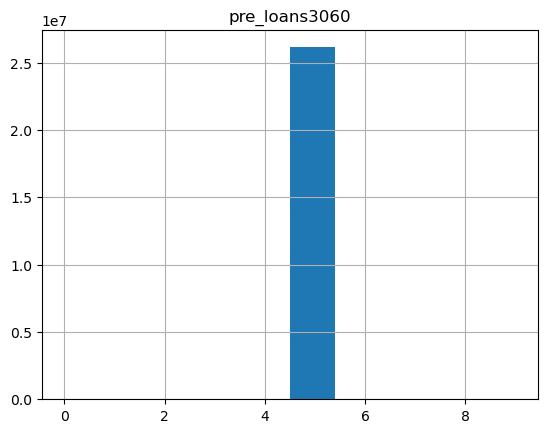

pre_loans3060
5    26147054
8       12924
2        2115
7         468
9         112
1          34
6           6
0           2
3           1
4           1
Name: count, dtype: int64


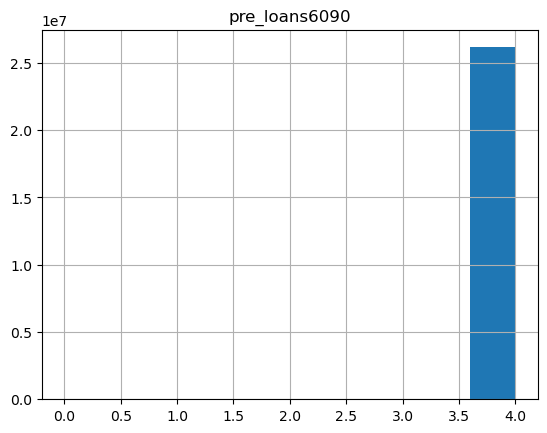

pre_loans6090
4    26161392
1        1236
2          76
3          12
0           1
Name: count, dtype: int64


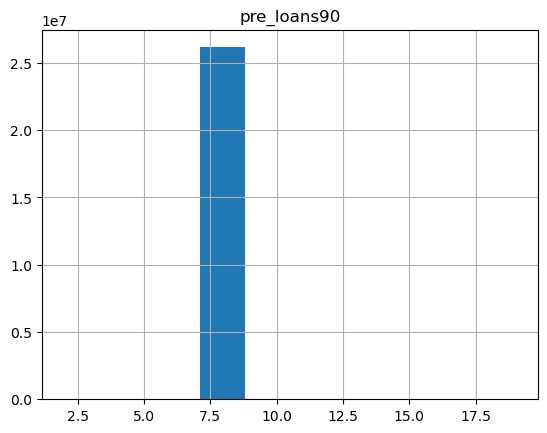

pre_loans90
8     26147777
14       11519
13        2191
19         791
2          278
10         120
3           41
Name: count, dtype: int64


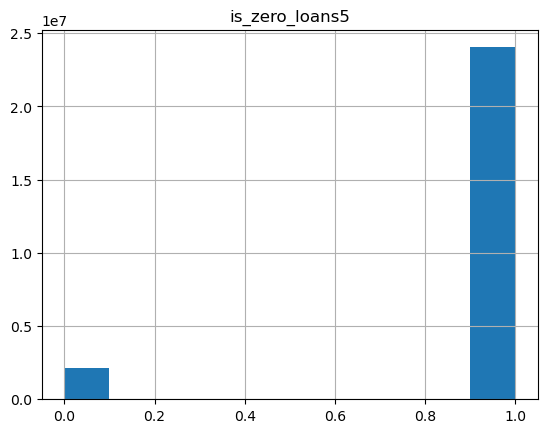

is_zero_loans5
1    24035861
0     2126856
Name: count, dtype: int64


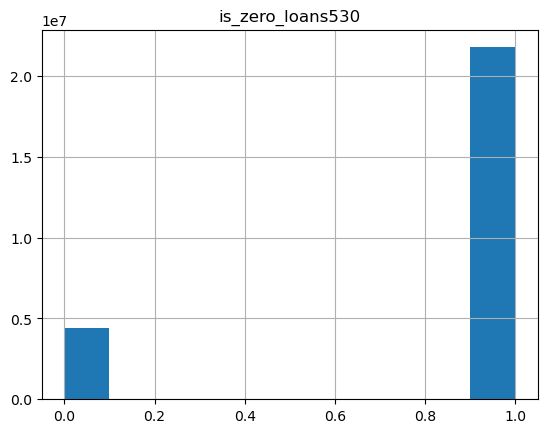

is_zero_loans530
1    21772900
0     4389817
Name: count, dtype: int64


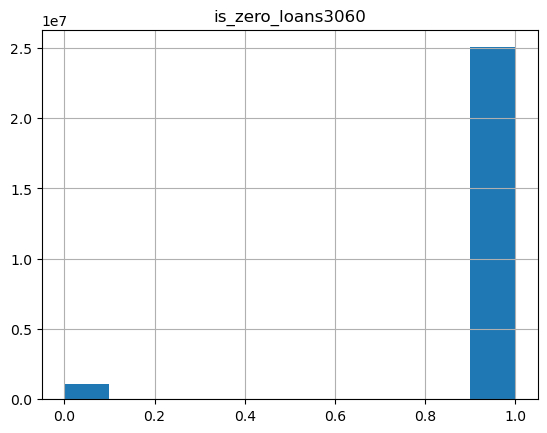

is_zero_loans3060
1    25047143
0     1115574
Name: count, dtype: int64


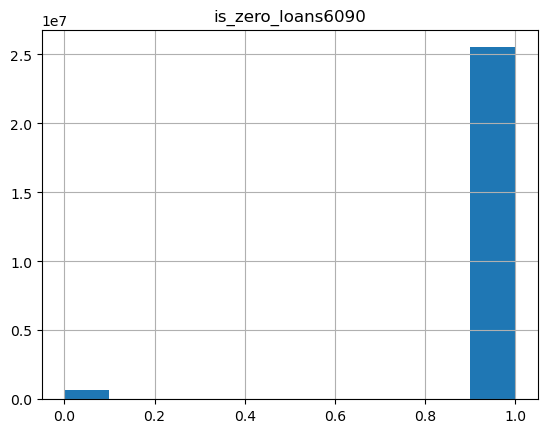

is_zero_loans6090
1    25519933
0      642784
Name: count, dtype: int64


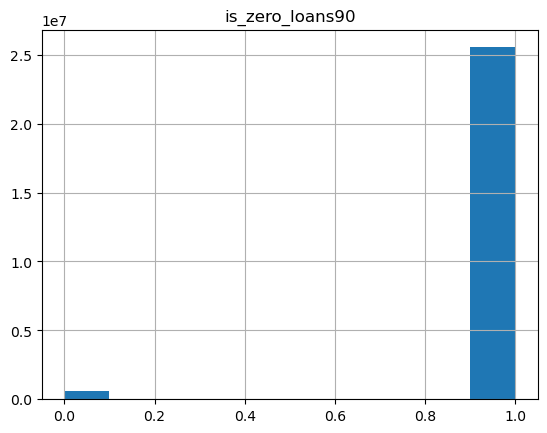

is_zero_loans90
1    25535248
0      627469
Name: count, dtype: int64


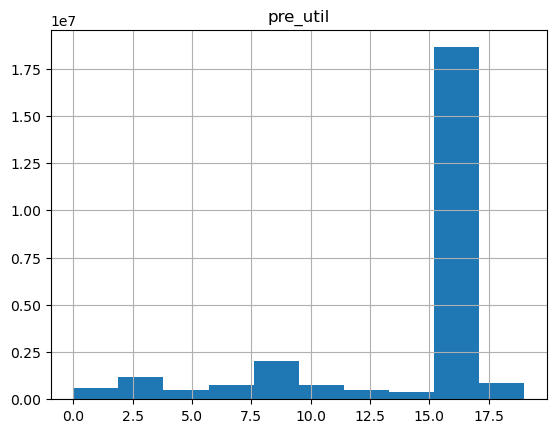

pre_util
16    18599223
9      1751629
3       962796
18      595518
6       487768
11      453764
15      380229
1       332213
7       289571
10      277074
0       273076
4       264892
12      255734
8       254544
19      241398
13      238202
2       235478
5       230661
17       26686
14       12261
Name: count, dtype: int64


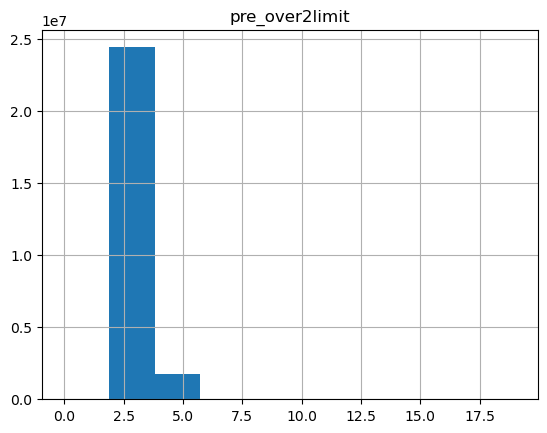

pre_over2limit
2     24403395
5      1717063
17       12381
6         7073
15        3031
4         2688
8         1784
14        1415
11        1390
13        1277
3         1270
19        1168
10        1168
12        1167
9         1125
0         1094
7         1079
1         1063
16        1051
18        1035
Name: count, dtype: int64


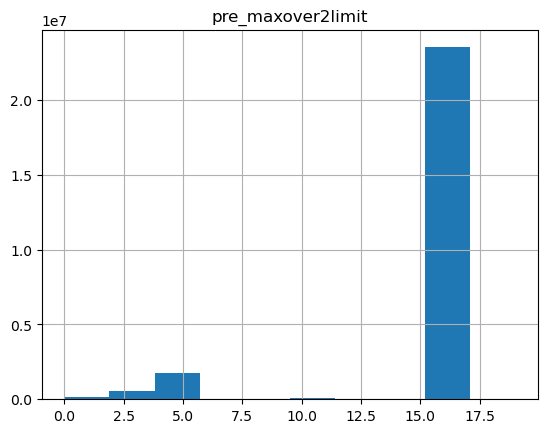

pre_maxover2limit
17    23505568
4      1721548
3       571242
0       161648
11       73027
15       24387
5        23609
9        23511
16        9324
8         6894
14        5335
12        4940
13        4648
10        4359
19        4264
2         4074
7         4073
1         3998
18        3472
6         2796
Name: count, dtype: int64


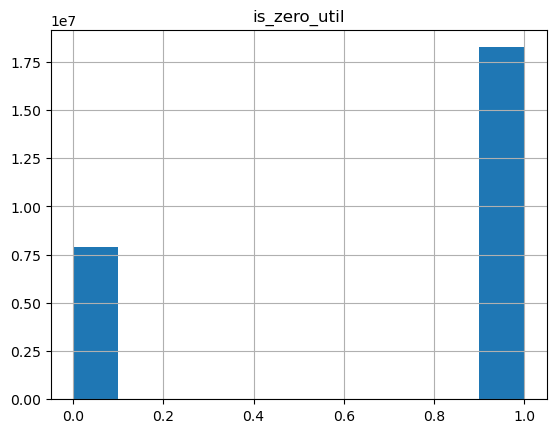

is_zero_util
1    18258067
0     7904650
Name: count, dtype: int64


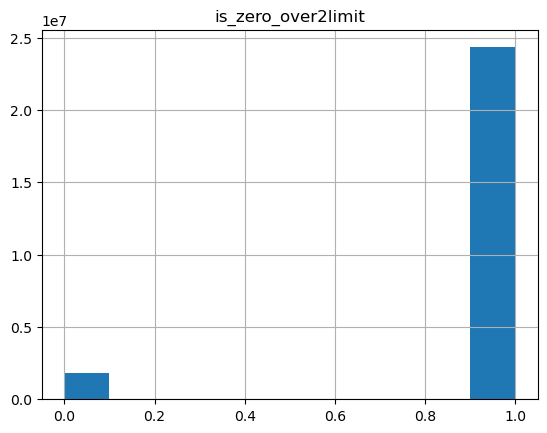

is_zero_over2limit
1    24334366
0     1828351
Name: count, dtype: int64


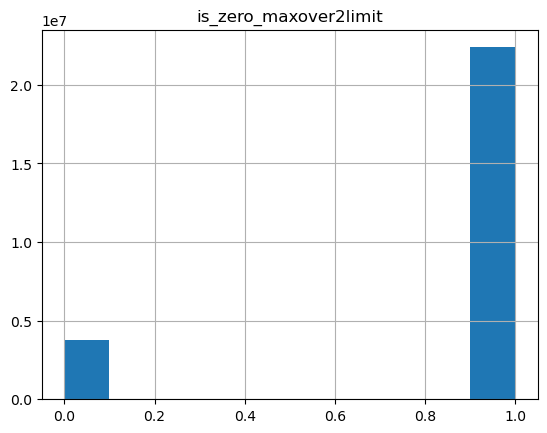

is_zero_maxover2limit
1    22383950
0     3778767
Name: count, dtype: int64


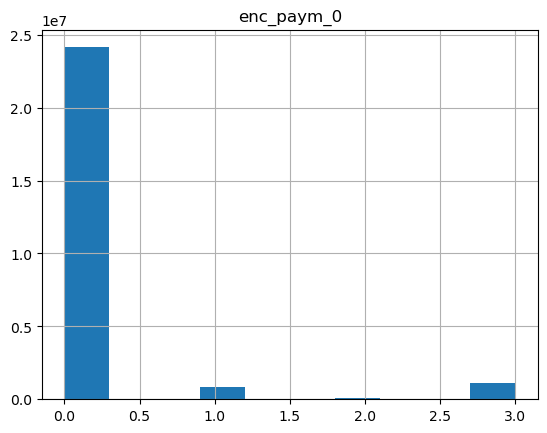

enc_paym_0
0    24136144
3     1109198
1      853844
2       63531
Name: count, dtype: int64


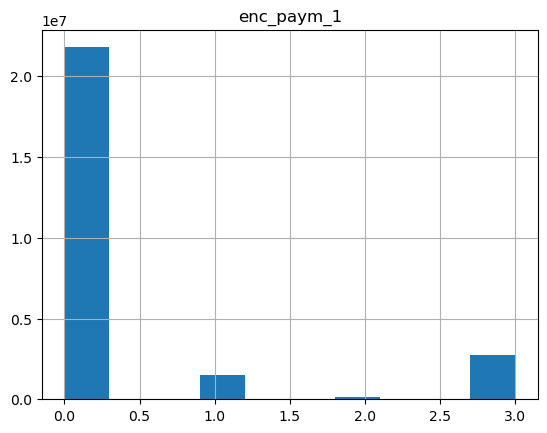

enc_paym_1
0    21792098
3     2733662
1     1521366
2      115591
Name: count, dtype: int64


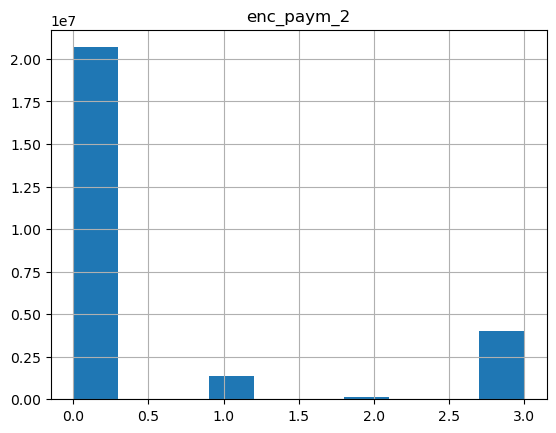

enc_paym_2
0    20686082
3     4008468
1     1362284
2      105883
Name: count, dtype: int64


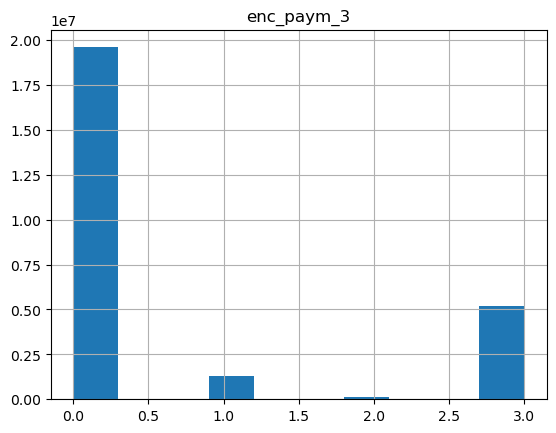

enc_paym_3
0    19601983
3     5167483
1     1292438
2      100813
Name: count, dtype: int64


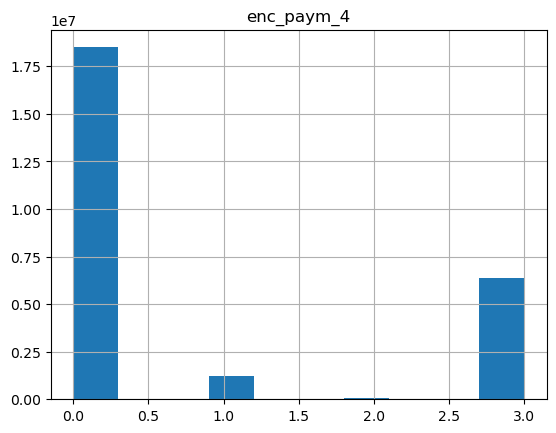

enc_paym_4
0    18500050
3     6356585
1     1212916
2       93166
Name: count, dtype: int64


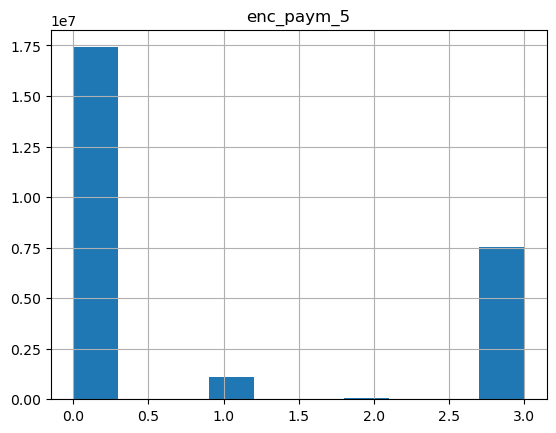

enc_paym_5
0    17409261
3     7542048
1     1125455
2       85953
Name: count, dtype: int64


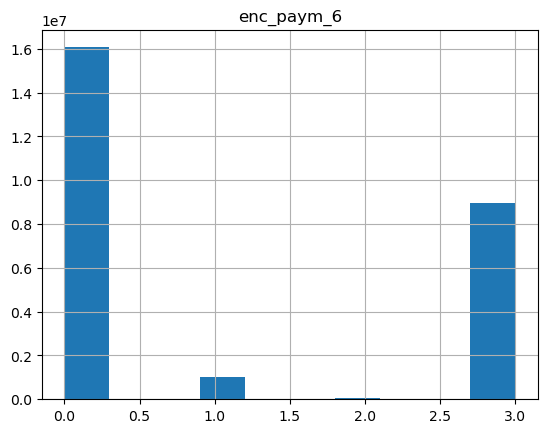

enc_paym_6
0    16073316
3     8980208
1     1034735
2       74458
Name: count, dtype: int64


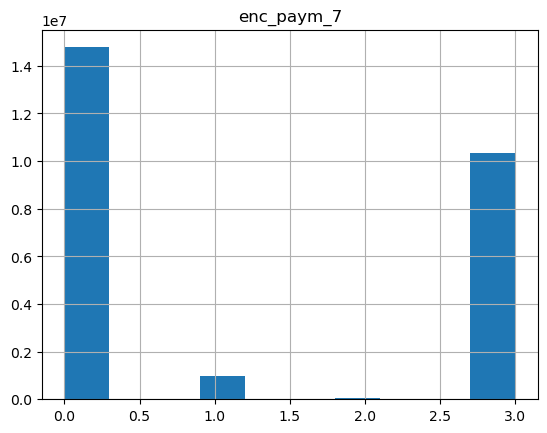

enc_paym_7
0    14780042
3    10354898
1      959831
2       67946
Name: count, dtype: int64


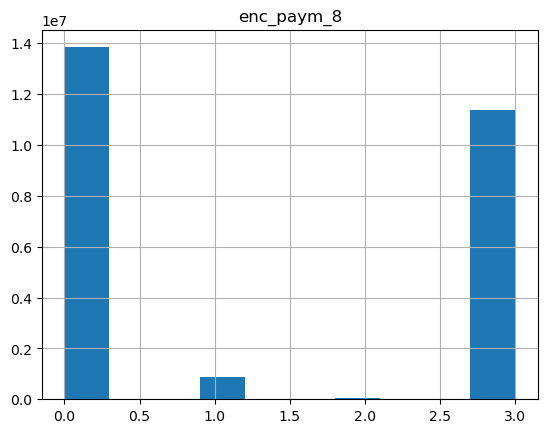

enc_paym_8
0    13842200
3    11370158
1      888696
2       61663
Name: count, dtype: int64


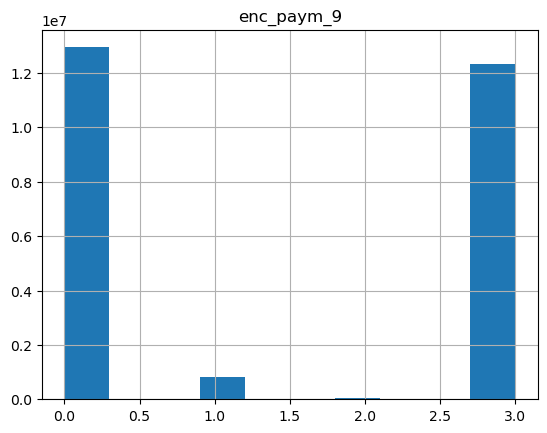

enc_paym_9
0    12943923
3    12343335
1      820177
2       55282
Name: count, dtype: int64


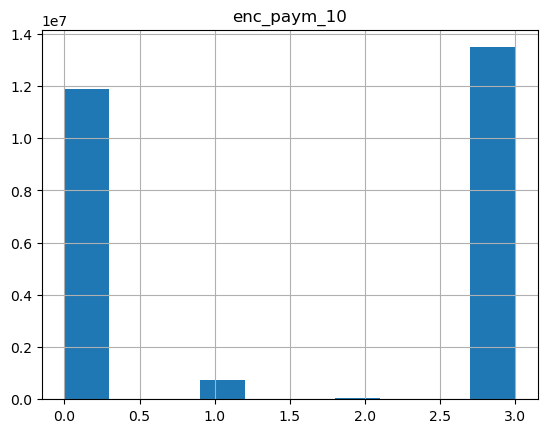

enc_paym_10
3    13486126
0    11886401
1      739935
2       50255
Name: count, dtype: int64


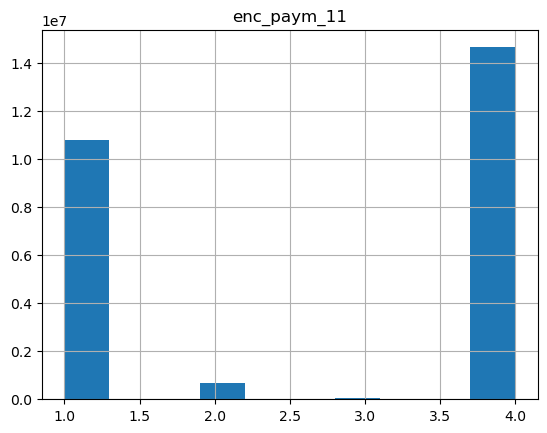

enc_paym_11
4    14650304
1    10796534
2      669937
3       45942
Name: count, dtype: int64


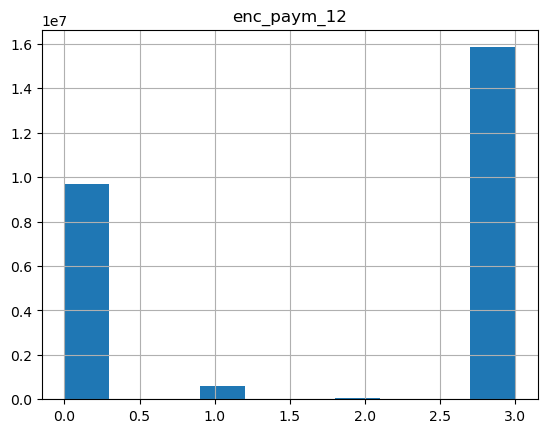

enc_paym_12
3    15844536
0     9676643
1      597470
2       44068
Name: count, dtype: int64


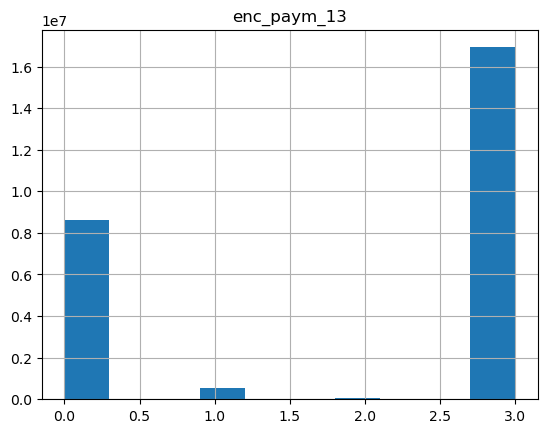

enc_paym_13
3    16924629
0     8638241
1      557416
2       42431
Name: count, dtype: int64


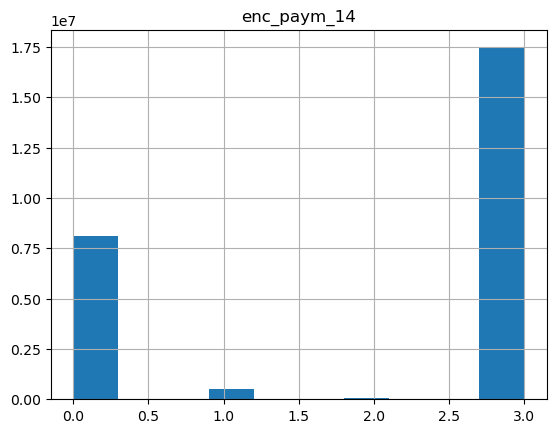

enc_paym_14
3    17485829
0     8103776
1      531865
2       41247
Name: count, dtype: int64


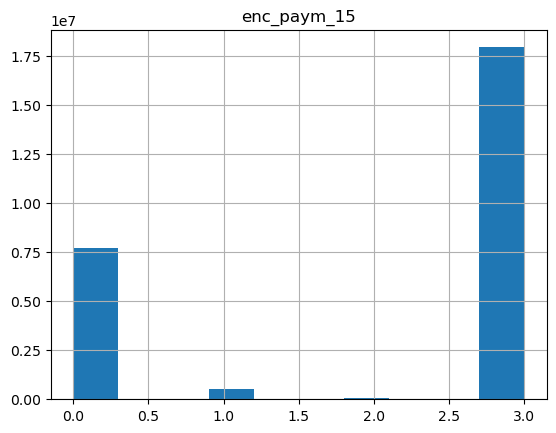

enc_paym_15
3    17925332
0     7689930
1      507580
2       39875
Name: count, dtype: int64


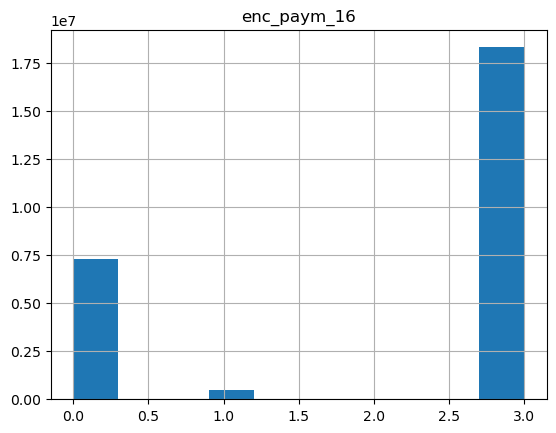

enc_paym_16
3    18322875
0     7315283
1      486053
2       38506
Name: count, dtype: int64


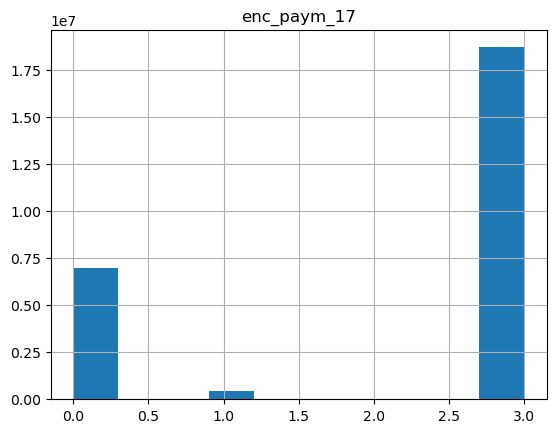

enc_paym_17
3    18697435
0     6965264
1      463426
2       36592
Name: count, dtype: int64


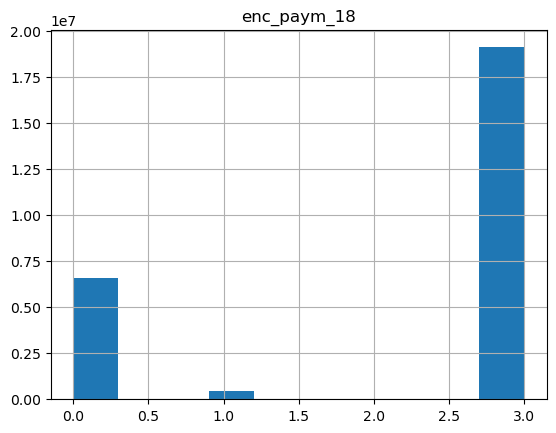

enc_paym_18
3    19094597
0     6591695
1      440732
2       35693
Name: count, dtype: int64


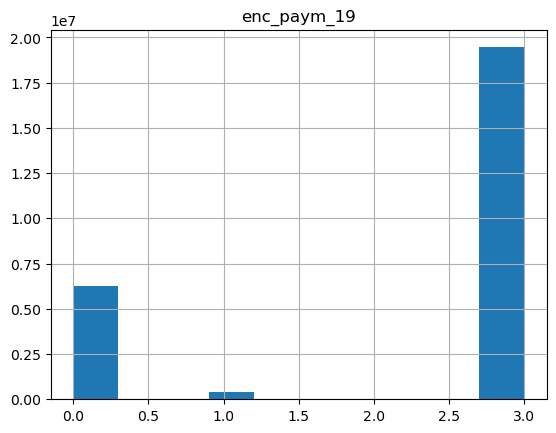

enc_paym_19
3    19453734
0     6253782
1      421092
2       34109
Name: count, dtype: int64


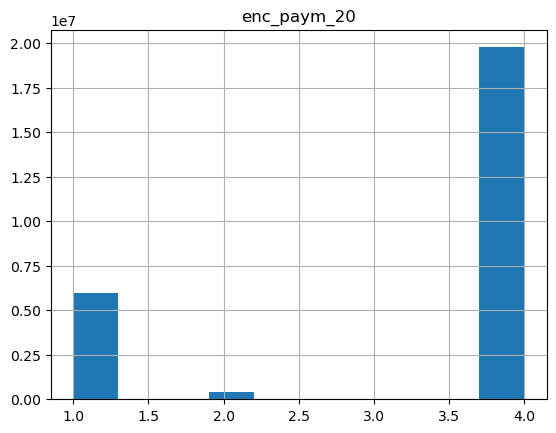

enc_paym_20
4    19762231
1     5965048
2      402922
3       32516
Name: count, dtype: int64


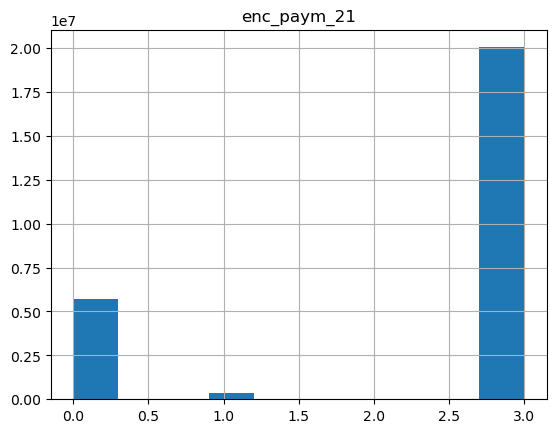

enc_paym_21
3    20049435
0     5697416
1      384819
2       31047
Name: count, dtype: int64


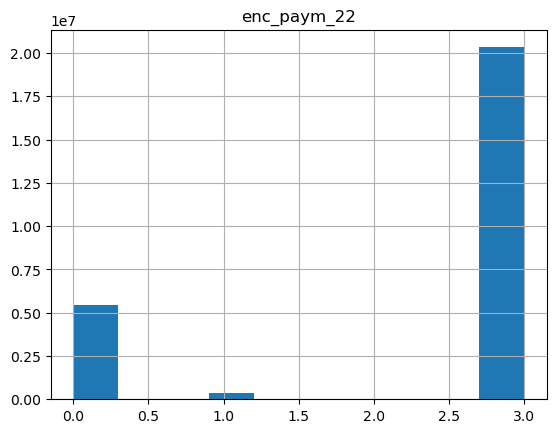

enc_paym_22
3    20332673
0     5435204
1      365132
2       29708
Name: count, dtype: int64


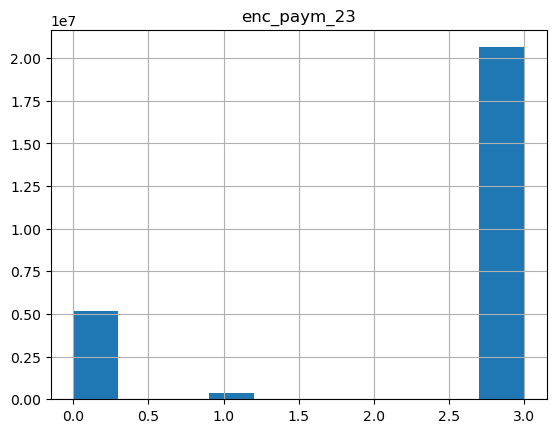

enc_paym_23
3    20634992
0     5157075
1      342900
2       27750
Name: count, dtype: int64


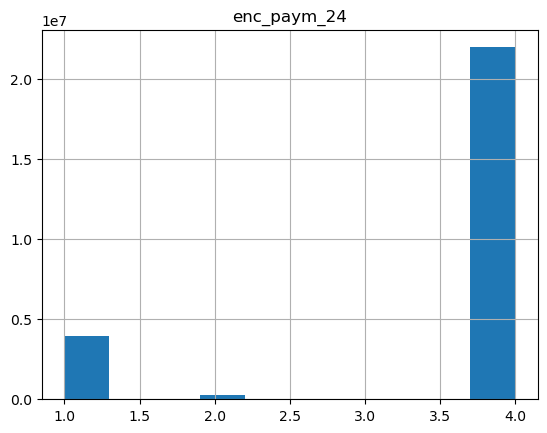

enc_paym_24
4    21966247
1     3919903
2      251452
3       25115
Name: count, dtype: int64


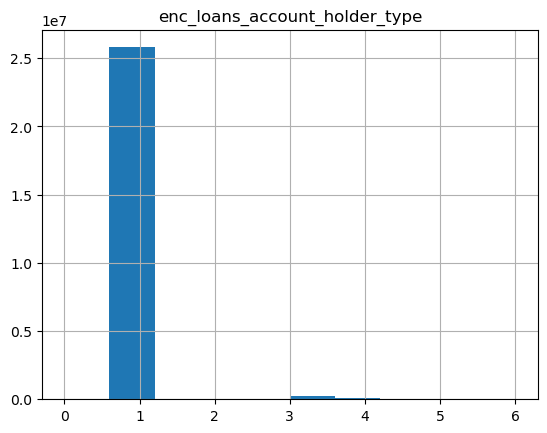

enc_loans_account_holder_type
1    25807322
3      213021
4      117422
6       20625
5        2232
2        2031
0          64
Name: count, dtype: int64


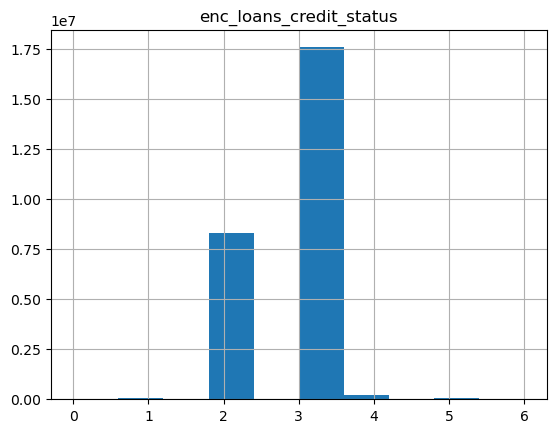

enc_loans_credit_status
3    17561773
2     8276203
4      201958
5       68431
1       48568
6        3803
0        1981
Name: count, dtype: int64


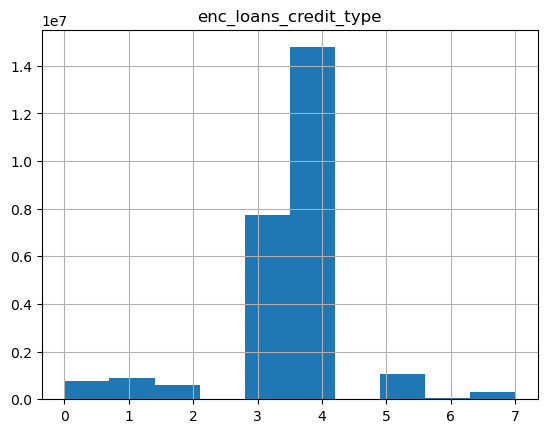

enc_loans_credit_type
4    14774986
3     7736233
5     1050346
1      880196
0      756480
2      617386
7      310217
6       36873
Name: count, dtype: int64


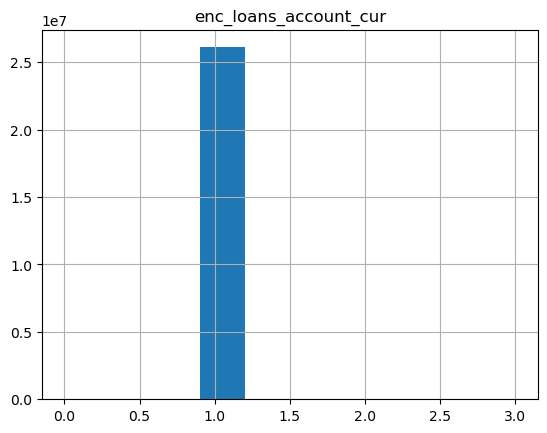

enc_loans_account_cur
1    26100882
2       53102
0        8550
3         183
Name: count, dtype: int64


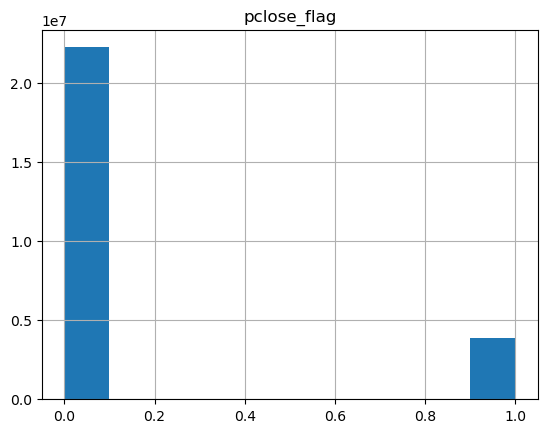

pclose_flag
0    22259294
1     3903423
Name: count, dtype: int64


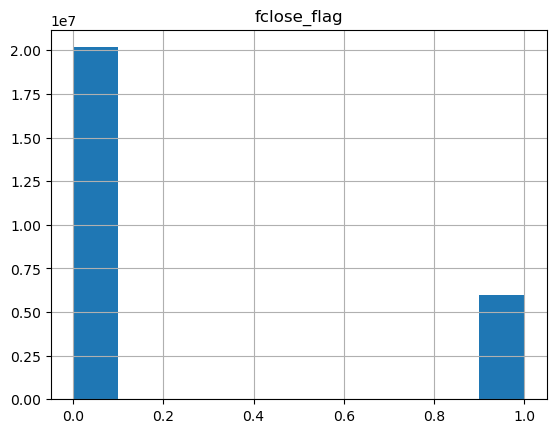

fclose_flag
0    20172292
1     5990425
Name: count, dtype: int64


In [16]:
for column in columns_data:
    df[column].hist()
    plt.title(column)
    plt.show()
    print(df[column].value_counts())

Исходя из графиков видно что признак pre_loans_total_overdue не несет никакой полезной информации, так как содержит во всех строках значение 0, за исключением одной.

In [15]:
df = df.drop(columns=['pre_loans_total_overdue'])

### Feature Engineering

Формируем новый датафрейм по количеству id размерностью 3 000 000 строк

В датасете есть признаки планового и фактического количества дней с даты открытия до даты закрытия, а также даты сбора информации. На основании данных признаков сделаем отедльный признак с двумя значениями 1 - если даты совпали, 0 если нет.

In [16]:
# Признак разности закрытия кредита
def pre_post(df):
    def minus_plus(x):
        if x == 0:
            return 1
        return 0

    df_tmp = df.copy()
    df_tmp['pre_term'] = df_tmp.apply(lambda x: minus_plus(x.pre_pterm - x.pre_fterm), axis = 1).astype('int8')
    df_tmp['pre_since'] = df_tmp.apply(lambda x: minus_plus(x.pre_since_opened - x.pre_since_confirmed), axis = 1).astype('int8')
    df_tmp['pre_till'] = df_tmp.apply(lambda x: minus_plus(x.pre_till_pclose - x.pre_till_fclose), axis = 1).astype('int8')

    col = ['pre_pterm', 'pre_fterm', 'pre_since_opened', 'pre_since_confirmed',
           'pre_till_pclose', 'pre_till_fclose']
    df_tmp = df_tmp.drop(columns = col)
    return df_tmp

In [17]:
df = pre_post(df)

Добавим признаки Невыплаченной суммы кредита, текущей просроченной задолженности к кредитному лимит и максимальной просроченной задолженности из признаков отношений к кредитному лимиту

In [18]:
def util_over_maxover(data):
    df = data.copy()
    # отношение просроченной задолженности к остатку по кредиту
    df['over_util'] = ((df['pre_over2limit']*df['pre_loans_credit_limit'])/(df['pre_loans_outstanding']+1)).astype('float16')
    # отношение текущей просрочки к следующему платежу 
    df['over_pay'] = ((df['pre_over2limit']*df['pre_loans_credit_limit'])/(df['pre_loans_next_pay_summ']+1)).astype('float16')
    # отношение максимальной просрочки к следующему платежу
    df['max_pay'] = (df['pre_loans_max_overdue_sum']/(df['pre_loans_next_pay_summ']+1)).astype('float16')
    return df

In [19]:
df = util_over_maxover(df)

Изучим признаки статусов платежей

In [20]:
df.loc[:, 'enc_paym_0':'enc_paym_24'][df.id == 1]

,enc_paym_0,enc_paym_1,enc_paym_2,enc_paym_3,enc_paym_4,enc_paym_5,enc_paym_6,enc_paym_7,enc_paym_8,enc_paym_9,...,enc_paym_15,enc_paym_16,enc_paym_17,enc_paym_18,enc_paym_19,enc_paym_20,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24
10,0,3,3,3,3,3,3,3,3,2,...,0,0,0,0,0,1,0,3,3,4
11,0,3,3,3,3,3,3,2,0,0,...,3,3,3,3,3,4,3,3,3,4
12,0,0,0,0,0,3,3,3,3,3,...,3,3,3,3,3,4,3,3,3,4
13,0,0,0,0,0,0,3,3,3,3,...,3,3,3,3,3,4,3,3,3,4
14,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,1
15,0,0,0,0,0,0,0,0,0,0,...,3,3,3,3,3,4,3,3,3,4
16,0,0,0,0,0,3,3,3,3,3,...,3,3,3,3,3,4,3,3,3,4
17,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,1
18,0,0,0,0,0,0,1,0,0,0,...,3,3,3,3,3,4,3,3,3,4
19,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


Судя по данным можно предположить что значение 3 означает платеж по кредиту, 0 и 1 то что кредита не было либо еще не был оформлен. Категории 2 и 4 не определены. Исходя из этой гипотезы введем три признака enc_without0 и enc_without1 - без кредита (значения 0 и 1), платежи по кредиту - enc_pay (значение 3) и неопределенные категории - enc_other2 и enc_other4. 

In [21]:
def enc(data):
    df = data.copy()
    columns = ['enc_without0', 'enc_without1', 'enc_other2', 'enc_pay', 'enc_other4']
    for number, column in enumerate(columns):
        df[column] = (df.loc[:, 'enc_paym_0':'enc_paym_24'] == number).sum(axis=1).astype('int8')
    columns_del = df.loc[:, 'enc_paym_0':'enc_paym_24'].columns
    # Добавляем дополнительный столбец с платежами для последующей агригации максимального значения
    df['enc_pay_max'] = df['enc_pay']
    df = df.drop(columns=columns_del)
        
    return df

In [22]:
df = enc(df)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26162717 entries, 0 to 26162716
Data columns (total 42 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   id                             int64  
 1   rn                             int8   
 2   pre_loans_credit_limit         int8   
 3   pre_loans_next_pay_summ        int8   
 4   pre_loans_outstanding          int8   
 5   pre_loans_max_overdue_sum      int8   
 6   pre_loans_credit_cost_rate     int8   
 7   pre_loans5                     int8   
 8   pre_loans530                   int8   
 9   pre_loans3060                  int8   
 10  pre_loans6090                  int8   
 11  pre_loans90                    int8   
 12  is_zero_loans5                 int8   
 13  is_zero_loans530               int8   
 14  is_zero_loans3060              int8   
 15  is_zero_loans6090              int8   
 16  is_zero_loans90                int8   
 17  pre_util                       int8   
 18  

Остальные признаки преобразуем из категориальных признаков с помощью OneHotEncoder. 

In [24]:
columns = ['pre_loans_max_overdue_sum', 'pre_loans_credit_cost_rate',
           'pre_loans5', 'pre_loans530', 'pre_loans3060', 'pre_loans6090', 'pre_loans90',
           'pre_loans_credit_limit', 'pre_loans_next_pay_summ', 'pre_loans_outstanding', 
           'pre_loans_credit_limit','enc_loans_credit_status', 'enc_loans_credit_type', 
           'enc_loans_account_cur', 'pre_util', 'pre_over2limit', 'pre_maxover2limit']
ohe = OneHotEncoder(sparse_output=False, dtype='int8', handle_unknown='ignore')
ohe.fit(df[columns])
ohe_full = ohe.transform(df[columns])
columns_ohe = ohe.get_feature_names_out()
df[columns_ohe] = ohe_full
df = df.drop(columns=columns)

К полученным столбцам признаков применим агрегирующие функции для группировки по id

In [25]:
def grouping_id(data):
    df = data.copy()
    # Определяем списки столбцов для разных агрегаций
    # 1. Столбцы с максимальным значением
    max_columns = ['rn', 'max_pay', 'enc_pay_max']
    
    # 2. Столбцы, которые нужно суммировать
    sum_columns = ['pre_term','pre_since','pre_till', 'is_zero_loans5', 
                   'is_zero_loans530', 'is_zero_loans3060', 'is_zero_loans6090',
                   'is_zero_loans90', 'is_zero_util', 'is_zero_over2limit', 
                   'is_zero_maxover2limit', 'pclose_flag', 'fclose_flag'] + list(columns_ohe)
    
    # 3. Столбцы, где нужно взять первое значение
    first_columns = ['enc_loans_account_holder_type', 'flag'] 
    
    #4. Столбцы, где берется среднее значение
    avg_columns = ['enc_without0','enc_without1','enc_pay','enc_other2', 'enc_other4','over_pay', 'over_util']
    
    # Формируем словарь агрегации
    agg_dict = {}
    agg_functions = {'max': max_columns, 'sum': sum_columns,
                     'first': first_columns, 'mean': avg_columns}
    
    for functions, columns in agg_functions.items():
        for column in columns:
            agg_dict[column] = functions
    
    # Выполняем группировку и агрегацию
    data_new = df.groupby('id').agg(agg_dict).reset_index()

    return data_new

In [26]:
# Применяем функцию группировки
data_new = grouping_id(df)

In [27]:
# Добавляем признаки процентного содержание статусов платежей
def col_paym(data):
    df = data.copy()
    columns_paym = ['enc_without0', 'enc_without1', 'enc_pay','enc_other2', 'enc_other4']
    for column in columns_paym:
        column_name = column + '_proc'
        df[column_name] = ((df[column] * 100) / (df['rn'] * 25)).astype('float16')
    return df

data_new = col_paym(data_new)

In [28]:
# Корректируем признак количества кредитных продуктов если был один то значение 0, если больше одного то 1
def count_credit(data):
    df = data.copy()
    df['rn'] = df['rn'].apply(lambda x: 0 if x == 1 else 1).astype('int8')
    return df
    
data_new = count_credit(data_new)

In [29]:
#Проверяем итоговую размерность готового датафрейма
data_new.shape

(3000000, 215)

In [30]:
data_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Columns: 215 entries, id to enc_other4_proc
dtypes: float16(6), float32(2), float64(5), int64(1), int8(201)
memory usage: 769.6 MB


In [31]:
data_new.head()

,id,rn,max_pay,enc_pay_max,pre_term,pre_since,pre_till,is_zero_loans5,is_zero_loans530,is_zero_loans3060,...,enc_pay,enc_other2,enc_other4,over_pay,over_util,enc_without0_proc,enc_without1_proc,enc_pay_proc,enc_other2_proc,enc_other4_proc
0,0,1,2.0,20,1,0,2,9,10,10,...,10.900000,0.000000,2.300000,6.590088,5.283008,-183.375000,-13.335938,-181.625000,-0.000000,-38.343750
1,1,1,2.0,22,0,1,1,12,10,12,...,11.500000,0.142857,2.000000,6.028320,4.166469,10.484375,1.595703,12.234375,0.151978,2.126953
2,2,1,1.0,22,0,0,0,3,2,2,...,11.666667,1.333333,2.333333,1.333333,0.855469,9.335938,3.554688,15.554688,1.777344,3.111328
3,3,1,1.0,21,0,2,1,15,15,15,...,7.000000,0.000000,1.600000,6.396484,4.971224,12.601562,1.176758,5.882812,0.000000,1.344727
4,4,0,1.0,22,0,0,0,1,1,1,...,22.000000,0.000000,3.000000,12.000000,6.000000,0.000000,0.000000,88.000000,0.000000,12.000000


Сохраним полученный датафрейм в файл

In [34]:
data_new.to_csv('data_new.csv', index = False)

# Modeling

In [32]:
# Определяем точку случайости
random_state = 42

In [33]:
x = data_new.drop(columns=['id', 'flag'])
y = data_new.flag
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=.7, random_state=random_state)

Определим три модели для выбора лучшей

In [37]:
models = [
    ('LogisticRegression', LogisticRegression(random_state=random_state,max_iter=5000, class_weight='balanced')),
    ('LGBMClassifier', lgb.LGBMClassifier(random_state=random_state, class_weight='balanced')),
    ('XGBoost', xgb.XGBClassifier(random_state=random_state))
]

In [38]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)

In [39]:
best_score = .0
best_model_name = None

for model_name, model in models:
    score = cross_val_score(model, x_train, y_train, cv=skf, scoring='roc_auc')
    print(f'Model: {model_name}, roc_auc: {score.mean():.4f}, roc_auc_std: {score.std():.4f}')

    if score.mean() > best_score:
        best_score = score.mean()
        best_model_name = model_name

print(f'best model: {best_model_name}, ROC AUC: {best_score:.4f}')

Model: LogisticRegression, roc_auc: 0.7332, roc_auc_std: 0.0013


  File "C:\Users\Anton\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Anton\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Anton\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Anton\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


[LightGBM] [Info] Number of positive: 49638, number of negative: 1350362
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.238161 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5218
[LightGBM] [Info] Number of data points in the train set: 1400000, number of used features: 199
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 49637, number of negative: 1350363
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.228729 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5202
[LightGBM] [Info] Number of data points in the train set: 1400000, number of used features: 198
[LightGBM]

Лучшая модель из представленных LGBMClassifier. Протестируем данную модель на тренировочной и тестовой выборке

In [34]:
clf = lgb.LGBMClassifier(random_state=random_state, class_weight='balanced', n_jobs=-1)
    
# Обучение
clf.fit(x_train, y_train)

# Предсказание
y_proba = clf.predict_proba(x_test)[:, 1]

roc_auc_test = roc_auc_score(y_test, y_proba)

print(f"ROC-AUC: {roc_auc_test:.4f}")

[LightGBM] [Info] Number of positive: 74456, number of negative: 2025544
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.355286 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5198
[LightGBM] [Info] Number of data points in the train set: 2100000, number of used features: 204
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
ROC-AUC: 0.7500


Значение ROC-AUC составило 0.75, что удовлетворяет условиям задания

Для улучшения предсказательной способности модели проверим все признаки на предсказательную способность модели и удалим те признаки которые влияют негативно на результат

In [42]:
roc_auc = roc_auc_test
columns = x_train.columns
columns_del = []
for column in columns:
    X_train = x_train.drop(columns = [column]+columns_del)
    X_test = x_test.drop(columns = [column]+columns_del)
    
    clf = lgb.LGBMClassifier(random_state=random_state, class_weight='balanced', n_jobs=-1)
        
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    roc = roc_auc_score(y_test, y_proba)
    if roc > roc_auc:
        roc_auc = roc
        columns_del.append(column)
    print(f"ROC-AUC без признака {column}: {roc_auc_score(y_test, y_proba):.4f}")

[LightGBM] [Info] Number of positive: 74456, number of negative: 2025544
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.325845 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5196
[LightGBM] [Info] Number of data points in the train set: 2100000, number of used features: 203
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
ROC-AUC без признака rn: 0.7499
[LightGBM] [Info] Number of positive: 74456, number of negative: 2025544
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.337158 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5181
[LightGBM] [Info] Number of data points in the train set: 2100000, numbe

In [43]:
columns_del

['pre_term',
 'pre_since',
 'pre_loans530_6',
 'pre_loans_credit_limit_10',
 'pre_util_0',
 'pre_util_16',
 'pre_maxover2limit_5']

In [35]:
columns_del = ['pre_term', 'pre_since', 'pre_loans530_6', 'pre_loans_credit_limit_10', 
               'pre_util_0', 'pre_util_16', 'pre_maxover2limit_5']

In [36]:
X_train = x_train.drop(columns = columns_del)
X_test = x_test.drop(columns = columns_del)

clf = lgb.LGBMClassifier(random_state=random_state, class_weight='balanced', n_jobs=-1)
    
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

roc_test = roc_auc_score(y_test, y_proba)
    
print(f"ROC-AUC {roc_test:.4f}")

[LightGBM] [Info] Number of positive: 74456, number of negative: 2025544
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.327517 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5104
[LightGBM] [Info] Number of data points in the train set: 2100000, number of used features: 197
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
ROC-AUC 0.7504


Опеределены признаки без которых модель показывает лучший результат:
'pre_term',
 'pre_since',
 'pre_loans530_6',
 'pre_loans_credit_limit_10',
 'pre_util_0',
 'pre_util_16',
 'pre_maxover2liit_11'

Подберем в гиперпараметры для модели. C помощью сетки поиска GridSearch поиск будет очень долгий, для оптимизации процесса используем RandomSearchCV

In [45]:
from sklearn.model_selection import RandomizedSearchCV

model = lgb.LGBMClassifier(random_state=random_state, class_weight='balanced', n_jobs=-1)

param_dist = {
    'num_leaves': list(range(30, 201, 10)),
    'max_depth': list(range(3, 26, 2)),
    'min_child_samples': list(range(5, 46, 2)),
    'subsample': list(np.linspace(0.6, 1.0, 5)),
    'subsample_freq': [0, 1],
    'colsample_bytree': list(np.linspace(0.6, 1.0, 5)),
    'reg_alpha': [0.0, 0.001, 0.01, 0.1, 0.5, 1.0], 
    'reg_lambda': [0.0, 0.001, 0.01, 0.1, 0.5, 1.0], 
    'min_split_gain': list(np.linspace(0.0, 0.05, 6))
}

# Случайный поиск
random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=70,
    cv=3,
    scoring='roc_auc',
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV score:", random_search.best_score_)

Fitting 3 folds for each of 70 candidates, totalling 210 fits
[LightGBM] [Info] Number of positive: 49638, number of negative: 1350362
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.210132 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5121
[LightGBM] [Info] Number of data points in the train set: 1400000, number of used features: 197
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

In [46]:
random_search.best_estimator_

LGBMClassifier(class_weight='balanced', colsample_bytree=0.9, max_depth=21,
               min_child_samples=41, min_split_gain=0.04, n_jobs=-1,
               num_leaves=80, random_state=42, reg_alpha=0.001, reg_lambda=1.0,
               subsample=0.6)

In [37]:
clf = lgb.LGBMClassifier(class_weight='balanced', colsample_bytree=0.9, max_depth=21,
               min_child_samples=41, min_split_gain=0.04, n_jobs=-1,
               num_leaves=80, random_state=random_state, reg_alpha=0.001, reg_lambda=1.0,
               subsample=0.6)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test, y_proba)
    
print(f"ROC-AUC {roc:.4f}")

[LightGBM] [Info] Number of positive: 74456, number of negative: 2025544
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.344730 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5086
[LightGBM] [Info] Number of data points in the train set: 2100000, number of used features: 188
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
ROC-AUC 0.7523


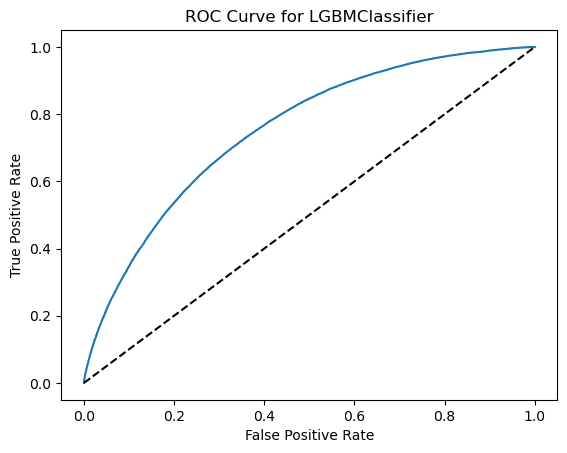

In [60]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, '-')
plt.plot([0, 1], [0, 1], 'k--')  
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for LGBMClassifier')
plt.show()

# Комплектация итогового проекта в pipeline

In [38]:
columns_data = data.columns[1:]
data[columns_data] = data[columns_data].astype('int8')
x = data
y = targets.flag.astype('int8')

In [39]:
def pre_loans(data):
    df = data.copy()
    columns_del = ['pre_loans_total_overdue']
    df = df.drop(columns=columns_del)
    return df
    
preparation = Pipeline(steps=[
    ('pre_loans_del', FunctionTransformer(pre_loans)),
    ('pre_post', FunctionTransformer(pre_post)),
    ('util_over_maxover', FunctionTransformer(util_over_maxover)),
    ('enc', FunctionTransformer(enc))
    ])

Так как ColumnTransformer возвращает преобразованный датафрейм в один массив, с типом данных float64, то для исключения нехватка памяти сделаем кастомный трансформер для преобразования категориальных переменных OneHotEncoder

In [41]:
class DataFrameOneHotEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns = None, **kwargs):
        self.columns = ['pre_loans_max_overdue_sum', 'pre_loans_credit_cost_rate',
           'pre_loans5', 'pre_loans530', 'pre_loans3060', 'pre_loans6090', 'pre_loans90',
           'pre_loans_credit_limit', 'pre_loans_next_pay_summ', 'pre_loans_outstanding', 
           'pre_loans_credit_limit','enc_loans_credit_status', 'enc_loans_credit_type', 
           'enc_loans_account_cur', 'pre_util', 'pre_over2limit', 'pre_maxover2limit']
        self.ohe = OneHotEncoder(sparse_output=False, dtype='int8', handle_unknown='ignore')
        self.ohe_cols_ = None

    def fit(self, X, y=None):
        self.ohe.fit(X[self.columns])
        self.ohe_cols_ = self.ohe.get_feature_names_out(self.columns)
        return self

    def transform(self, X):
        X = X.copy()
        ohe_data = self.ohe.transform(X[self.columns])
        X[self.ohe_cols_] = ohe_data
        X = X.drop(columns=self.columns)
        return X

In [43]:
post_preparation = Pipeline(steps=[
    ('columns_paym', FunctionTransformer(col_paym)),
    ('count_credit', FunctionTransformer(count_credit))
])

In [44]:
def filter_data(data):
    df = data.copy()
    columns_del = ['id', 'pre_term', 'pre_since', 'pre_loans530_6', 'pre_loans_credit_limit_10',
                   'pre_util_0', 'pre_util_16', 'pre_maxover2limit_5']
    df = df.drop(columns=columns_del)
    return df

data_delete = Pipeline(steps=[
    ('filter_data', FunctionTransformer(filter_data))
    ])

Прямая группировка признаков не возможна в pipeline, но по факту она необходима для выполнения всего алгоритма расчетов, создадим класс трансформер выполняющий манипуляции группировки

In [69]:
class GroupByIdTransformer(BaseEstimator, TransformerMixin):
    """
    Агрегация данных по идентификатору id.
    
    Параметры:
        max_cols : список столбцов, для которых берётся максимум.
        sum_cols : список столбцов, для которых берётся сумма.
        first_cols : список столбцов, для которых берётся первое значение.
        mean_cols : список столбцов, для которых берётся среднее.

    """
    def __init__(self, max_columns=None, sum_columns=None, first_columns=None, avg_columns=None):
        self.max_columns = ['rn', 'max_pay', 'enc_pay_max']
        self.sum_columns = [
            'pre_term', 'pre_since', 'pre_till', 'is_zero_loans5', 
            'is_zero_loans530', 'is_zero_loans3060', 'is_zero_loans6090', 
            'is_zero_loans90', 'is_zero_util', 'is_zero_over2limit', 
            'is_zero_maxover2limit','pclose_flag', 'fclose_flag'
        ]
        self.first_columns = ['enc_loans_account_holder_type']
        self.avg_columns = [
            'enc_without0', 'enc_without1', 'enc_pay',
            'enc_other2', 'enc_other4', 'over_pay', 'over_util'
        ]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        import pandas as pd
        
        X = pd.DataFrame(X)
        X = X.copy()
        # Определяем все столбцы, которые не входят в списки
        all_cols = set(X.columns)
        known_cols = set(self.max_columns + self.sum_columns + self.first_columns + self.avg_columns)
        # Добавляем столбцы, не входящие в списки (кроме id), в список суммирования
        additional_sum_cols = [col for col in all_cols if col not in known_cols and col != 'id']
        sum_cols_final = self.sum_columns + additional_sum_cols

        agg_dict = {}
        agg_functions = {'max': self.max_columns, 'sum': sum_cols_final,
                         'first': self.first_columns, 'mean': self.avg_columns}

        for functions, columns in agg_functions.items():
            for column in columns:
                agg_dict[column] = functions

        # Группируем по id
        data_new = X.groupby('id').agg(agg_dict).reset_index()
        return data_new

group_transformer = GroupByIdTransformer()

In [46]:
model = lgb.LGBMClassifier(class_weight='balanced', colsample_bytree=0.9, max_depth=21,
                           min_child_samples=41, min_split_gain=0.04, n_jobs=-1, num_leaves=80, 
                           random_state=random_state, reg_alpha=0.001, reg_lambda=1.0,
                           subsample=0.6)

In [70]:
pipe = Pipeline(steps=[
    ('preparation', preparation),
    ('preprocessor', DataFrameOneHotEncoder()),
    ('grouping', GroupByIdTransformer()),
    ('post_preparation', post_preparation),
    ('delete_columns', data_delete),
    ('LGBMClassifier', model)
])

pipe.fit(x, y)

[LightGBM] [Info] Number of positive: 106442, number of negative: 2893558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.524969 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5107
[LightGBM] [Info] Number of data points in the train set: 3000000, number of used features: 189
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


Pipeline(steps=[('preparation',
                 Pipeline(steps=[('pre_loans_del',
                                  FunctionTransformer(func=<function pre_loans at 0x0000018B800972E0>)),
                                 ('pre_post',
                                  FunctionTransformer(func=<function pre_post at 0x0000018B80094040>)),
                                 ('util_over_maxover',
                                  FunctionTransformer(func=<function util_over_maxover at 0x0000018B80094860>)),
                                 ('enc',
                                  FunctionTransformer(func=<function enc a...
                                  FunctionTransformer(func=<function count_credit at 0x0000018B800968E0>))])),
                ('delete_columns',
                 Pipeline(steps=[('filter_data',
                                  FunctionTransformer(func=<function filter_data at 0x0000018B800949A0>))])),
                ('LGBMClassifier',
                 LGBMClassifier(class_weight='balanced', colsample_bytree=0.9,
                                max_depth=21, min_child_samples=41,
                                min_split_gain=0.04, n_jobs=-1, num_leaves=80,
                                random_state=42, reg_alpha=0.001,
                                reg_lambda=1.0, subsample=0.6))])

In [48]:
file_name = 'model/risk_managment.pkl'

with open(file_name, 'wb') as file:
    dill.dump({
        'model': pipe,
        'metadata': {
            'name': 'Risk-managment prediction model',
            'author': 'Anton Safonov',
            'version': 1,
            'date': datetime.now(),
            'type': 'LGBMClassifier',
            'ROC-AUC': roc
        }
    }, file)